## Importing libraries

In [ ]:
import sys
import os
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
from lib import Dense, Tanh, Sigmoid, MSE, SGD, Network
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

## 1. Gradient checking

### Initialize inputs, outputs and layers

In [1]:
np.random.seed(43) #to get the same random data every time for reproducability
x = np.array([[0.1,0.98]])
y = np.array ([[1]])
test_layer = Dense(2,1)
test_loss = MSE()


NameError: name 'np' is not defined

### Analytical gradient

In [ ]:
out = test_layer.forward(x)
loss = test_loss.forward(out,y)
gradient_lib = test_loss.backward()
test_layer.backward(gradient_lib)

array([[-0.95988129,  3.38785774]])

Isolating one of the gradients

In [ ]:
analytical_grad = test_layer.dW[0, 0]  
print(analytical_grad)

-0.3729143623181157


### Calculating numerical gradient

In [ ]:
epsilon = 1e-5
original_w = test_layer.W[0, 0]

# Forward pass with W + epsilon
test_layer.W[0, 0] = original_w + epsilon
out_plus = test_layer.forward(x)
loss_plus = test_loss.forward(out_plus, y)

# Forward pass with W - epsilon
test_layer.W[0, 0] = original_w - epsilon
out_minus = test_layer.forward(x)
loss_minus = test_loss.forward(out_minus, y)

Analyzing the difference between them

In [ ]:
test_layer.W[0, 0] = original_w

numerical_grad = (loss_plus - loss_minus) / (2 * epsilon)

print(f"Analytical Gradient (Backprop): {analytical_grad:.8f}")
print(f"Numerical Gradient (Formula):   {numerical_grad:.8f}")
print(f"Difference:                     {abs(analytical_grad - numerical_grad):.8e}\n")


Analytical Gradient (Backprop): -0.37291436
Numerical Gradient (Formula):   -0.37291456
Difference:                     2.00000689e-07



---
## 2. The XOR problem

### Initialising inputs, outputs and layers

In [ ]:
x = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

hidden_layer_1 = Dense(2,4)
activation1 = Tanh()
hidden_layer_2 = Dense(4,1)
activation2 = Sigmoid()

### Buidling the network

In [ ]:
Layers = [hidden_layer_1,activation1,hidden_layer_2,activation2]
NN = Network(Layers, MSE(), SGD(learning_rate=0.1, momentum=0.9))

### Training

In [ ]:
Epochs = 1000
error = np.zeros(shape=(Epochs,1))
for Epoch in range(Epochs):
    error[Epoch] = NN.train_step(x,y)


### Testing


--- Final Results ---
Input: [0 0] | True: 0 | Predicted: 0.0278
Input: [0 1] | True: 1 | Predicted: 0.9615
Input: [1 0] | True: 1 | Predicted: 0.9799
Input: [1 1] | True: 0 | Predicted: 0.0394


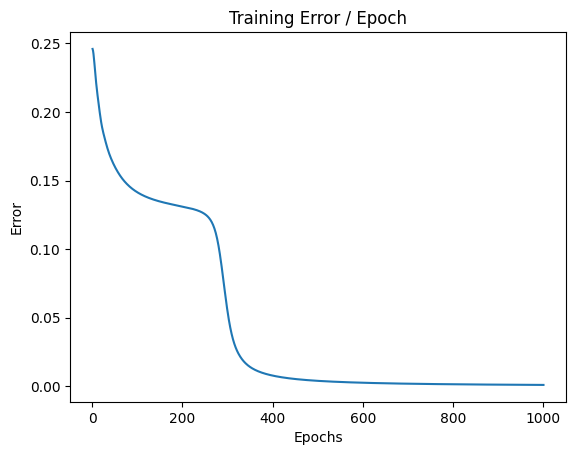

In [ ]:
print("\n--- Final Results ---")
predictions = NN.forward(x)

for i in range(len(x)):
    print(f"Input: {x[i]} | True: {y[i][0]} | Predicted: {predictions[i][0]:.4f}")

plt.plot(np.arange(1,Epochs+1),error)
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Training Error / Epoch")
plt.show()

---
## 3. Autoencoder

In [ ]:
# 